# LEMURS Audio Modeling Pipeline: From Database to Deep Learning Regression

This educational notebook demonstrates the end-to-end workflow for extracting, processing, visualizing, and modeling audio survey responses from the LEMURS PostgreSQL database to predict weekly **PHQ-9 depression scores**.

### Workflow Pipeline:
1. **Database Scraping & Label Linking**: Querying PostgreSQL for raw audio binary records (`audio_response` table) and linking them to their corresponding weekly **PHQ-9 survey total scores** (`phq9_score`).
2. **Audio Decoding & Interactive Playback**: Converting raw mobile audio formats (**Android 3GP** and **Apple iPhone M4A**) to `.wav` and listening to them inline using `IPython.display.Audio`.
3. **Audio Hyperparameters & Educational Concepts**: Comprehensive breakdown of key audio processing terms (`sr`, `n_fft`, `hop_length`, `n_mels`, `n_mfcc`, PCM, Spectrograms).
4. **Audio Signal Processing & Visualizations**: Computing and plotting **Log-Mel Spectrograms** and **MFCCs** using `torchaudio`.
5. **PyTorch Dataset & DataLoader**: Building an `AudioDataset` that yields Log-Mel Spectrogram tensors and continuous `phq9_score` regression target labels.
6. **Simple Deep Learning Regression Model**: Training a 2D Convolutional Neural Network (`SimpleAudioRegressor`) to regress weekly PHQ-9 depression scores from audio spectrogram features using MSE Loss.


In [32]:
import os
import sys
import tempfile
import subprocess
import shutil
import wave
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from dotenv import load_dotenv

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T

# Load project environment variables and modules
root_dir = os.path.abspath("..")
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

load_dotenv(os.path.join(root_dir, ".env"))

from src.utils.database_service import DatabaseService

print(f"PyTorch Version:    {torch.__version__}")
print(f"TorchAudio Version: {torchaudio.__version__}")


PyTorch Version:    2.12.0
TorchAudio Version: 2.11.0


## Step 1: Database Data Extraction & PHQ-9 Label Linking
We connect to the PostgreSQL database using `DatabaseService` to extract raw binary records from the `audio_response` table and join them with the `answer` table to calculate each user's **PHQ-9 weekly survey total score** (`phq9_score`).


In [33]:
# Initialize DatabaseService
db = DatabaseService()
print(f"Connecting to database '{db.dbname}' at {db.host}:{db.port}...")
assert db.connect(), "Failed to connect to database."

cursor = db.connection.cursor()

# Query audio responses joined with weekly PHQ-9 survey total scores
query = """
    SELECT ar.id as sample_id, ar.survey_response_id, sr.app_user_id, um.umass_id, 
           q.question as question_text, 
           COALESCE(SUM(CAST(a.answer AS FLOAT)), 0.0) as phq9_score,
           ar.timestamp, LENGTH(ar.audio_data) as raw_size_bytes, ar.audio_data
    FROM audio_response ar
    JOIN survey_response sr ON ar.survey_response_id = sr.id
    LEFT JOIN umass_id um ON sr.app_user_id = um.app_user_id
    LEFT JOIN question q ON ar.audio_question_id = q.id
    LEFT JOIN answer a ON a.survey_response_id = sr.id
    WHERE LENGTH(ar.audio_data) > 100
    GROUP BY ar.id, ar.survey_response_id, sr.app_user_id, um.umass_id, q.question, ar.timestamp, ar.audio_data
    ORDER BY ar.id
"""
cursor.execute(query)
rows = cursor.fetchall()
db.disconnect()

# Convert to DataFrame
df_audio = pd.DataFrame(rows, columns=[
    "sample_id", "survey_response_id", "app_user_id", "umass_id", "question_text",
    "phq9_score", "timestamp", "raw_size_bytes", "audio_data"
])

# Inspect container format based on FTYP brand header
def detect_brand(raw_bytes):
    raw = bytes(raw_bytes)
    if len(raw) >= 12:
        brand = raw[4:12]
        if brand == b'ftypM4A ':
            return 'Apple iPhone (M4A / AAC)'
        elif brand == b'ftyp3gp4':
            return 'Android Device (3GP / AMR)'
    return 'Unknown'

df_audio['format'] = df_audio['audio_data'].apply(detect_brand)

print(f"Scraped {len(df_audio)} audio responses with linked PHQ-9 total scores.\n")
print("PHQ-9 Score Summary Statistics (Continuous Regression Target):")
print(df_audio['phq9_score'].describe())

df_audio[['sample_id', 'app_user_id', 'umass_id', 'question_text', 'format', 'phq9_score', 'raw_size_bytes']].head(10)


Connecting to database 'lemurs' at 130.215.43.34:5432...
Scraped 154 audio responses with linked PHQ-9 total scores.

PHQ-9 Score Summary Statistics (Continuous Regression Target):
count    154.000000
mean       7.805195
std        6.670663
min        0.000000
25%        3.000000
50%        6.000000
75%       12.000000
max       30.000000
Name: phq9_score, dtype: float64


,sample_id,app_user_id,umass_id,question_text,format,phq9_score,raw_size_bytes
0,1,7,10008,I wanted to die,Android Device (3GP / AMR),1.0,62575
1,2,11,10005,I thought about taking my life,Android Device (3GP / AMR),3.0,45323
2,3,14,10010,I thought about taking my life,Android Device (3GP / AMR),2.0,45035
3,4,17,10014,I thought about taking my life,Android Device (3GP / AMR),4.0,40095
4,5,15,10012,I thought about taking my life,Android Device (3GP / AMR),8.0,38360
5,6,11,10005,"Since the last prompt, have you…",Android Device (3GP / AMR),2.0,35987
6,7,14,10010,"Since the last prompt, have you…",Android Device (3GP / AMR),1.0,54179
7,8,17,10014,"Since the last prompt, have you…",Android Device (3GP / AMR),3.0,51511
8,9,7,10008,"Since the last prompt, have you…",Android Device (3GP / AMR),2.0,63475
9,10,15,10012,"Since the last prompt, have you…",Android Device (3GP / AMR),7.0,24088


## Step 2: Audio Decoding & Interactive Inline Audio Playback
The database stores raw mobile audio binary:
- **Android**: `3gp` container with `AMR` narrowband speech codec.
- **Apple iPhone**: `m4a` container with `AAC` audio codec.

Below we decode both an **Android recording** and an **Apple iPhone recording (Participant 10033)** using cross-platform in-memory PyAV (`av`) decoding, convert to 16 kHz `.wav` PCM, and test interactive audio playback directly inside Jupyter using `IPython.display.Audio`.


In [34]:
def raw_bytes_to_pcm(raw_bytes: bytes, target_sr: int = 16000) -> np.ndarray:
    """Convert raw 3GP / M4A binary bytes to 16kHz float32 PCM numpy array.
    Uses PyAV (FFmpeg bindings) for cross-platform in-memory decoding.
    """
    try:
        import av
        import io
        container = av.open(io.BytesIO(bytes(raw_bytes)))
        stream = container.streams.audio[0]
        resampler = av.AudioResampler(format="flt", layout="mono", rate=target_sr)
        pcm_frames = []
        for frame in container.decode(stream):
            for rf in resampler.resample(frame):
                pcm_frames.append(rf.to_ndarray())
        if pcm_frames:
            return np.concatenate(pcm_frames, axis=1).squeeze(0)
    except Exception:
        pass

    with tempfile.NamedTemporaryFile(suffix=".tmp", delete=False) as src_f, \
         tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as dst_f:
        src_path, dst_path = src_f.name, dst_f.name
        src_f.write(bytes(raw_bytes))

    try:
        converted = False
        if shutil.which("ffmpeg"):
            cmd = ["ffmpeg", "-y", "-i", src_path, "-ar", str(target_sr), "-ac", "1", dst_path]
            res = subprocess.run(cmd, capture_output=True, text=True)
            if res.returncode == 0:
                converted = True
        if not converted and shutil.which("afconvert"):
            cmd = ["afconvert", "-f", "WAVE", "-d", f"LEI16@{target_sr}", src_path, dst_path]
            res = subprocess.run(cmd, capture_output=True, text=True)
            if res.returncode == 0:
                converted = True

        with wave.open(dst_path, "rb") as wf:
            frames = wf.readframes(wf.getnframes())
            audio = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0
            if wf.getnchannels() > 1:
                audio = audio.reshape(-1, wf.getnchannels()).mean(axis=1)
        return audio
    finally:
        for p in [src_path, dst_path]:
            if os.path.exists(p): os.remove(p)

# Select one Android recording and one Apple iPhone participant recording (Participant 10033, Sample 92)
android_row = df_audio[df_audio['format'] == 'Android Device (3GP / AMR)'].iloc[0]
iphone_row = df_audio[df_audio['sample_id'] == 92].iloc[0]

for label, row in [("Android Device (3GP / AMR)", android_row), ("Apple iPhone (M4A / AAC - Participant 10033)", iphone_row)]:
    audio_pcm = raw_bytes_to_pcm(row['audio_data'], target_sr=16000)
    duration_sec = len(audio_pcm) / 16000.0
    print(f"=========================================================================")
    print(f"Device Category: {label}")
    print(f"Sample ID:       {row['sample_id']} (Participant UMass ID: {row['umass_id']})")
    print(f"Question:        '{row['question_text']}'")
    print(f"PHQ-9 Score:     {row['phq9_score']} points")
    print(f"Duration:        {duration_sec:.2f} seconds ({len(audio_pcm)} PCM samples at 16kHz)")
    print(f"=========================================================================")
    display(Audio(audio_pcm, rate=16000))


Device Category: Android Device (3GP / AMR)
Sample ID:       1 (Participant UMass ID: 10008)
Question:        'I wanted to die'
PHQ-9 Score:     1.0 points
Duration:        32.46 seconds (519328 PCM samples at 16kHz)


Device Category: Apple iPhone (M4A / AAC - Participant 10033)
Sample ID:       92 (Participant UMass ID: 10033)
Question:        'Since the last prompt, have you… '
PHQ-9 Score:     15.0 points
Duration:        16.04 seconds (256704 PCM samples at 16kHz)


## Step 3: Educational Primer — Audio Processing Terms & Parameters Explained

Before extracting features, here is a beginner-friendly breakdown of core audio signal processing terms and hyperparameters used in speech machine learning:

---

### 1. Key Hyperparameters Breakdown

| Parameter | Value | Name | What it Means & Why it Matters |
| :--- | :---: | :--- | :--- |
| **`sr`** | `16000` | **Sampling Rate** | The number of discrete audio amplitude measurements taken per second ($16,000\text{ Hz}$). According to the **Nyquist-Shannon Sampling Theorem**, $16\text{ kHz}$ captures frequencies up to $8\text{ kHz}$ ($f_{\text{max}} = \frac{\text{sr}}{2}$), which covers the full human speech frequency spectrum (vowel formants, consonant fricatives, pitch). $16\text{ kHz}$ is the universal standard for modern speech ML models (Whisper, Wav2Vec2, HuBERT). |
| **`n_fft`** | `1024` | **FFT Window Size** | The window length for the **Fast Fourier Transform** (FFT), which converts time-domain audio snippets into frequency spectra. At $\text{sr}=16000$, a window of $1024$ samples represents $64\text{ milliseconds}$ of audio per slice ($\frac{1024}{16000}\text{s}$). This strikes an optimal balance between frequency resolution (fine pitch detail) and time resolution. |
| **`hop_length`** | `512` | **Frame Shift (Hop)** | The number of audio samples the sliding FFT window advances between consecutive frames. $512$ samples = $32\text{ ms}$. Because $\text{hop\_length} = 512$ is half of $\text{n\_fft} = 1024$, adjacent windows overlap by $50\%$. This ensures smooth continuous transitions in time without missing short acoustic speech events. |
| **`n_mels`** | `80` | **Mel Filterbank Bins** | The number of frequency channels in the **Mel Spectrogram**. Human hearing does **NOT** perceive pitch linearly; we are far more sensitive to pitch variations at lower frequencies ($0\text{--}2000\text{ Hz}$) than higher frequencies ($4000\text{--}8000\text{ Hz}$). The **Mel Scale** maps linear Hz frequencies onto a non-linear perceptual pitch scale. $80$ Mel bins compress the $513$ raw FFT frequency bins into an optimal 2D image representation for neural networks. |
| **`n_mfcc`** | `13` | **MFCC Coefficients** | **Mel-Frequency Cepstral Coefficients**. Computed by taking the Discrete Cosine Transform (DCT) of the log-Mel spectrogram. The first $13$ coefficients capture the overall vocal tract geometry and speech timbre while discarding fine pitch harmonics. |

---

### 2. Audio Processing Terminology Dictionary

- **PCM (Pulse-Code Modulation)**: The raw, uncompressed digital representation of a continuous sound wave. Stored as an array of amplitude values $x[t] \in [-1.0, 1.0]$.
- **STFT (Short-Time Fourier Transform)**: The mathematical algorithm that slides a window of size `n_fft` across the audio signal every `hop_length` samples to generate a 2D Time-Frequency spectrum.
- **Log Scaling (`torch.log(mel + 1e-9)`)**: Human volume perception is logarithmic (decibels). Taking the logarithm converts multiplicative noise into additive noise and compresses the dynamic range so neural network gradients remain stable.
- **Spectrogram as a 2D Image**: A Log-Mel Spectrogram matrix has shape `[channels=1, n_mels=80, time_frames]`. Because it behaves exactly like a single-channel grayscale image (width = time, height = pitch frequency), 2D Convolutional Neural Networks (CNNs) can process audio spectrograms just like image classification models!


## Step 4: Feature Extraction & Device Visualizations with `torchaudio`
Below we compute and plot Waveforms, **Log-Mel Spectrograms**, and **MFCCs** for both the **Apple iPhone recording** and the **Android recording** side-by-side using `torchaudio` and `matplotlib`.


Android Sample  ID 1: Waveform=torch.Size([1, 519328]), LogMel=(80, 1015), PHQ9=1.0
iPhone  Sample  ID 92: Waveform=torch.Size([1, 256704]), LogMel=(80, 502), PHQ9=15.0


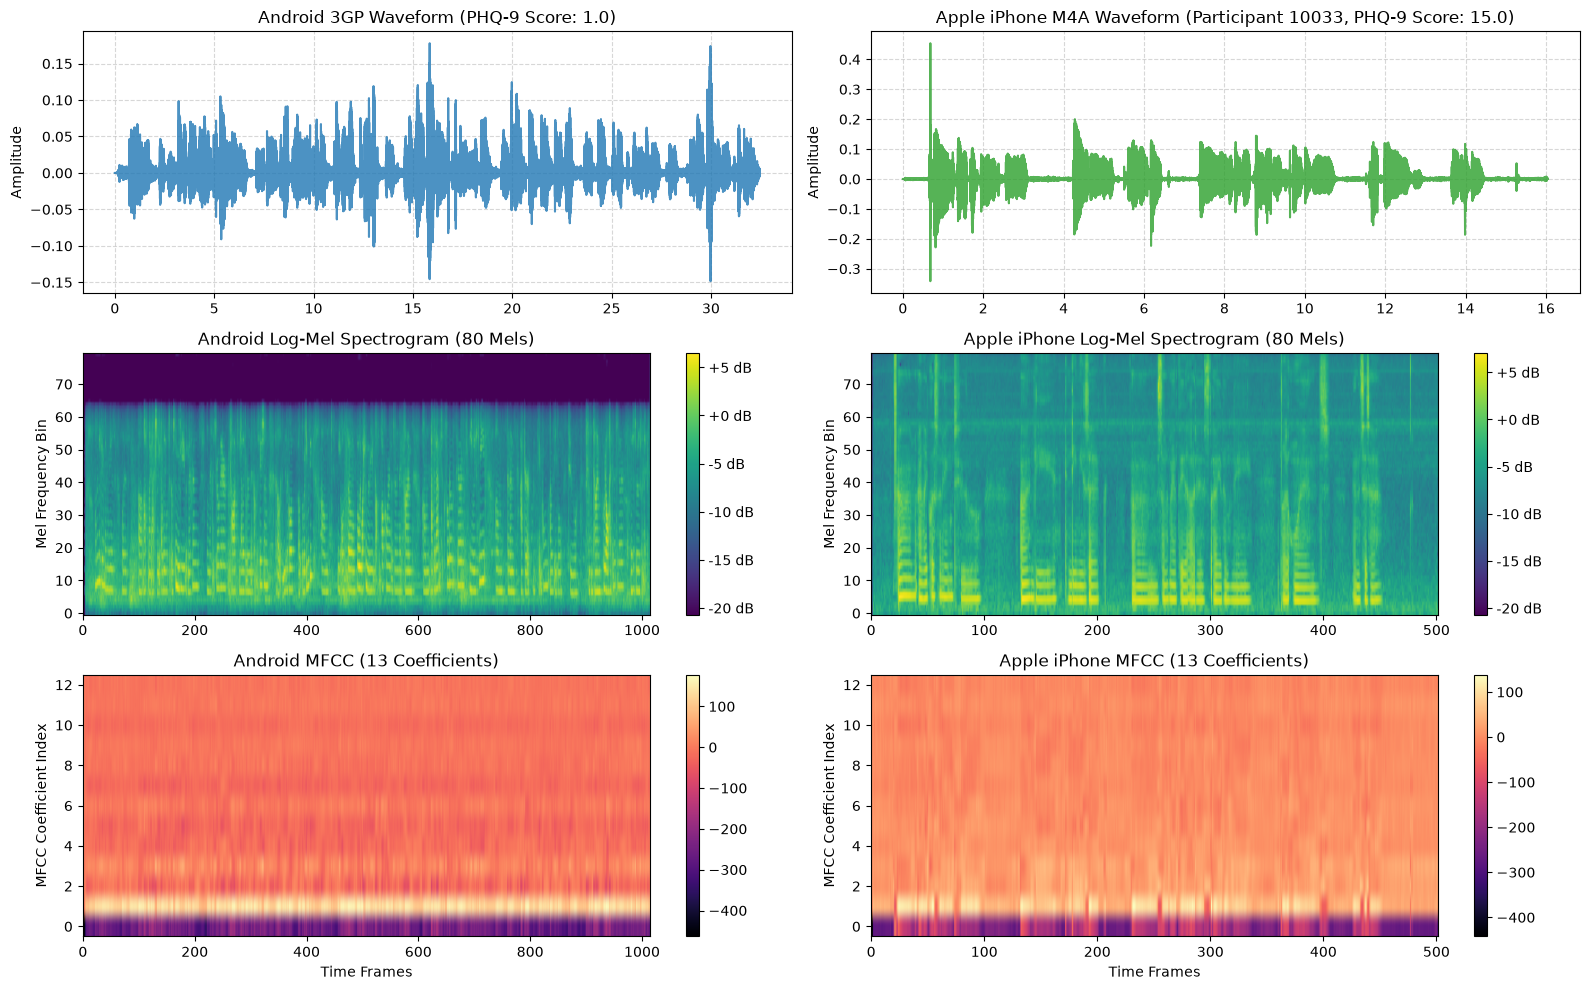

In [35]:
sr = 16000
n_fft = 1024
hop_length = 512
n_mels = 80
n_mfcc = 13

# Initialize PyTorch torchaudio feature extractors
mel_transform = T.MelSpectrogram(sample_rate=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
mfcc_transform = T.MFCC(sample_rate=sr, n_mfcc=n_mfcc, melkwargs={"n_fft": n_fft, "hop_length": hop_length, "n_mels": n_mels})

# Extract raw PCM waveforms as PyTorch Tensors [1, num_samples]
pcm_android = raw_bytes_to_pcm(android_row['audio_data'], target_sr=sr)
pcm_iphone = raw_bytes_to_pcm(iphone_row['audio_data'], target_sr=sr)

wav_android = torch.from_numpy(pcm_android).unsqueeze(0)
wav_iphone = torch.from_numpy(pcm_iphone).unsqueeze(0)

# Compute 2D Log-Mel Spectrograms [1, 80, time_frames] and Log-scaling
log_mel_android = torch.log(torch.clamp(mel_transform(wav_android), min=1e-9))[0].numpy()
log_mel_iphone = torch.log(torch.clamp(mel_transform(wav_iphone), min=1e-9))[0].numpy()

# Compute MFCC matrices [1, 13, time_frames]
mfcc_android = mfcc_transform(wav_android)[0].numpy()
mfcc_iphone = mfcc_transform(wav_iphone)[0].numpy()

print(f"Android Sample  ID {android_row['sample_id']}: Waveform={wav_android.shape}, LogMel={log_mel_android.shape}, PHQ9={android_row['phq9_score']}")
print(f"iPhone  Sample  ID {iphone_row['sample_id']}: Waveform={wav_iphone.shape}, LogMel={log_mel_iphone.shape}, PHQ9={iphone_row['phq9_score']}")

# Plotting Side-by-Side Comparison
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

# Row 1: Time-Domain Waveforms
t_android = np.linspace(0, len(pcm_android)/sr, len(pcm_android))
t_iphone = np.linspace(0, len(pcm_iphone)/sr, len(pcm_iphone))

axes[0, 0].plot(t_android, pcm_android, color='#1f77b4', alpha=0.8)
axes[0, 0].set_title(f"Android 3GP Waveform (PHQ-9 Score: {android_row['phq9_score']})")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

axes[0, 1].plot(t_iphone, pcm_iphone, color='#2ca02c', alpha=0.8)
axes[0, 1].set_title(f"Apple iPhone M4A Waveform (Participant 10033, PHQ-9 Score: {iphone_row['phq9_score']})")
axes[0, 1].set_ylabel("Amplitude")
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Row 2: Log-Mel Spectrograms
im1 = axes[1, 0].imshow(log_mel_android, aspect='auto', origin='lower', cmap='viridis')
axes[1, 0].set_title("Android Log-Mel Spectrogram (80 Mels)")
axes[1, 0].set_ylabel("Mel Frequency Bin")
fig.colorbar(im1, ax=axes[1, 0], format='%+2.0f dB')

im2 = axes[1, 1].imshow(log_mel_iphone, aspect='auto', origin='lower', cmap='viridis')
axes[1, 1].set_title("Apple iPhone Log-Mel Spectrogram (80 Mels)")
axes[1, 1].set_ylabel("Mel Frequency Bin")
fig.colorbar(im2, ax=axes[1, 1], format='%+2.0f dB')

# Row 3: MFCCs
im3 = axes[2, 0].imshow(mfcc_android, aspect='auto', origin='lower', cmap='magma')
axes[2, 0].set_title("Android MFCC (13 Coefficients)")
axes[2, 0].set_xlabel("Time Frames")
axes[2, 0].set_ylabel("MFCC Coefficient Index")
fig.colorbar(im3, ax=axes[2, 0])

im4 = axes[2, 1].imshow(mfcc_iphone, aspect='auto', origin='lower', cmap='magma')
axes[2, 1].set_title("Apple iPhone MFCC (13 Coefficients)")
axes[2, 1].set_xlabel("Time Frames")
axes[2, 1].set_ylabel("MFCC Coefficient Index")
fig.colorbar(im4, ax=axes[2, 1])

plt.tight_layout()
plt.show()


## Step 5: PyTorch Dataset & DataLoader (PHQ-9 Score Target)
We define `AudioDataset`, which processes database rows, computes Log-Mel Spectrogram tensors `[1, 80, time_frames]`, and attaches the continuous `phq9_score` regression target label (`torch.float32`).


In [36]:
class AudioDataset(Dataset):
    """PyTorch Dataset for Audio Responses targeting continuous PHQ-9 depression scores."""
    def __init__(self, metadata: pd.DataFrame, sample_rate: int = 16000, target_duration_sec: float = 10.0):
        self.metadata = metadata.reset_index(drop=True)
        self.sample_rate = sample_rate
        self.target_samples = int(sample_rate * target_duration_sec)
        self.mel_transform = T.MelSpectrogram(sample_rate=sample_rate, n_fft=1024, hop_length=512, n_mels=80)

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        pcm = raw_bytes_to_pcm(row['audio_data'], target_sr=self.sample_rate)
        waveform = torch.from_numpy(pcm).unsqueeze(0)

        # Pad or crop to fixed target_samples (10 seconds = 160,000 PCM samples)
        curr_len = waveform.shape[-1]
        if curr_len < self.target_samples:
            waveform = torch.nn.functional.pad(waveform, (0, self.target_samples - curr_len))
        else:
            waveform = waveform[:, :self.target_samples]

        # Compute Log-Mel Spectrogram [1, 80, 313]
        mel_spec = self.mel_transform(waveform)
        log_mel_spec = torch.log(torch.clamp(mel_spec, min=1e-9))

        phq9_val = float(row.get('phq9_score', 0.0))

        return {
            "sample_id": row["sample_id"],
            "mel_spectrogram": log_mel_spec,                      # [1, 80, 313]
            "phq9_target": torch.tensor(phq9_val, dtype=torch.float32),  # Continuous target
            "question_text": row["question_text"]
        }

# Create Dataset and DataLoader
dataset = AudioDataset(metadata=df_audio.head(40), sample_rate=16000, target_duration_sec=10.0)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

print(f"Dataset size: {len(dataset)} samples with continuous PHQ-9 score targets.")

# Inspect a single batch from DataLoader
for batch in dataloader:
    print("\nDataLoader Batch Inspection:")
    print(f"  Batch Mel Spectrogram shape: {batch['mel_spectrogram'].shape} -> [batch_size=4, channels=1, mels=80, frames=313]")
    print(f"  Batch PHQ-9 Targets:        {batch['phq9_target'].tolist()}")
    break


Dataset size: 40 samples with continuous PHQ-9 score targets.

DataLoader Batch Inspection:
  Batch Mel Spectrogram shape: torch.Size([4, 1, 80, 313]) -> [batch_size=4, channels=1, mels=80, frames=313]
  Batch PHQ-9 Targets:        [11.0, 3.0, 2.0, 1.0]


## Step 6: Simple Deep Learning Regression Model (`SimpleAudioRegressor`)
We define a 2D Convolutional Neural Network (`SimpleAudioRegressor`) in PyTorch. The model receives 2D Log-Mel Spectrogram image tensors `[batch_size, 1, 80, time_frames]` and outputs a continuous scalar prediction for the weekly **PHQ-9 depression score**.


In [37]:
class SimpleAudioRegressor(nn.Module):
    """Lightweight 2D CNN for continuous PHQ-9 depression score regression."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        # Linear layer outputs single continuous scalar prediction
        self.regressor = nn.Linear(64, 1)

    def forward(self, x):
        # x shape: [batch_size, 1, 80, time_frames]
        feat = self.features(x)         # [batch_size, 64, 1, 1]
        feat = torch.flatten(feat, 1)   # [batch_size, 64]
        out = self.regressor(feat)      # [batch_size, 1]
        return out.squeeze(-1)          # [batch_size]

# Initialize Model, Loss Function (MSE), and Optimizer
model = SimpleAudioRegressor()
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("SimpleAudioRegressor Architecture:")
print(model)


SimpleAudioRegressor Architecture:
SimpleAudioRegressor(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (regressor): Linear(in_features=64, out_features=1, bias=True)
)


## Step 7: Model Training & Regression Evaluation
Below we execute a training loop demonstrating the forward pass, MSE loss calculation, backpropagation, and MAE (Mean Absolute Error) metrics.


In [38]:
num_epochs = 5
print(f"Starting training for {num_epochs} epochs...\n")

model.train()
for epoch in range(1, num_epochs + 1):
    total_mse = 0.0
    total_mae = 0.0
    total_samples = 0
    
    for batch in dataloader:
        inputs = batch['mel_spectrogram']
        targets = batch['phq9_target']
        
        optimizer.zero_grad()
        preds = model(inputs)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()
        
        total_mse += loss.item() * inputs.size(0)
        total_mae += torch.sum(torch.abs(preds - targets)).item()
        total_samples += inputs.size(0)
        
    avg_mse = total_mse / total_samples
    avg_mae = total_mae / total_samples
    print(f"Epoch [{epoch}/{num_epochs}] | MSE Loss: {avg_mse:.4f} | MAE: {avg_mae:.2f} points")

print("\nTraining completed successfully!")

# Evaluation pass on sample batch
model.eval()
with torch.no_grad():
    sample_batch = next(iter(dataloader))
    predictions = model(sample_batch['mel_spectrogram'])
    targets = sample_batch['phq9_target']

print("\nSample Regression Output (PHQ-9 Score Predictions):")
for i in range(len(predictions)):
    sample_id = sample_batch['sample_id'][i].item()
    pred_val = predictions[i].item()
    true_val = targets[i].item()
    err = abs(pred_val - true_val)
    print(f"Sample {sample_id:<3}: Actual PHQ-9 = {true_val:>4.1f} | Predicted PHQ-9 = {pred_val:>5.2f} | Abs Error = {err:.2f} pts")


Starting training for 5 epochs...

Epoch [1/5] | MSE Loss: 29.1990 | MAE: 4.00 points
Epoch [2/5] | MSE Loss: 25.9306 | MAE: 3.61 points
Epoch [3/5] | MSE Loss: 23.3420 | MAE: 3.34 points
Epoch [4/5] | MSE Loss: 21.7147 | MAE: 3.19 points
Epoch [5/5] | MSE Loss: 19.9394 | MAE: 2.98 points

Training completed successfully!

Sample Regression Output (PHQ-9 Score Predictions):
Sample 38 : Actual PHQ-9 =  2.0 | Predicted PHQ-9 =  1.45 | Abs Error = 0.55 pts
Sample 22 : Actual PHQ-9 =  1.0 | Predicted PHQ-9 =  1.72 | Abs Error = 0.72 pts
Sample 5  : Actual PHQ-9 =  8.0 | Predicted PHQ-9 =  1.33 | Abs Error = 6.67 pts
Sample 40 : Actual PHQ-9 =  3.0 | Predicted PHQ-9 =  1.77 | Abs Error = 1.23 pts


## Step 8: Summary & Key Takeaways

| Stage | Operations Performed | Core Libraries |
| :--- | :--- | :--- |
| **1. Scraping & Labels** | Extracted `audio_data` bytes from PostgreSQL and linked **PHQ-9 weekly total score** (`phq9_score`) | `DatabaseService` (`psycopg2`), `pandas` |
| **2. Decoding & Playback** | Converted **Android 3GP** and **Apple iPhone M4A (Participant 10033)** to `.wav` for audio playback | PyAV (`av`), `IPython.display.Audio` |
| **3. Educational Primer** | Detailed breakdown of `sr=16000`, `n_fft=1024`, `hop_length=512`, `n_mels=80`, `n_mfcc=13` | Theoretical reference guide |
| **4. Feature Extraction** | Computed time-domain waveform, 80-channel Log-Mel Spectrogram, and 13-dim MFCC | `torchaudio.transforms` |
| **5. Dataset & Batching** | Standardized sample rate (16 kHz), padded to 10s fixed duration, created `DataLoader` | `torch.utils.data.Dataset`, `DataLoader` |
| **6. Regression Model** | Passed Log-Mel 2D spectrograms into a 2D CNN (`SimpleAudioRegressor`) with `MSELoss` | `torch.nn`, `torch.optim` |
